# Feature Engineering
The dataset contains 20 features related to Telco customers


### ✅ Handling missing values
- Check remaining missing values and handle missing as NaN


In [8]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('../data/raw/telco-customer-churn-ibm.csv')

# Drop customerID
df.drop('customerID', axis=1, inplace=True)

# Convert TotalCharges to numeric (handle missing as NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("\nMissing data TotalCharges: ", df['TotalCharges'].isna().sum())

# Fill missing TotalCharges with median (skip if all NaN)
if not df['TotalCharges'].isna().all():
    df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
else:
    print("Warning: 'TotalCharges' is entirely NaN after conversion!")

print("Missing data TotalCharges: " ,df['TotalCharges'].isna().sum())
# Map target variable to binary
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

print(f"\nShape after cleaning: {df.shape}\n")


Missing data TotalCharges:  11
Missing data TotalCharges:  0

Shape after cleaning: (7043, 20)



### 🔄 Encode categorical variables

Encoding categorical variables is a vital step in preparing data for machine learning. 

- Identify categorical columns (e.g., Contract, PaymentMethod, InternetService)
- Choosing encoding method:
  - One-hot encoding: creates separate binary columns - best for unordered categories
  - It is widely used categorical encoding technique.
  - the idea is to represent each category as a binary vector that ML algorithms can understand.
  - Label encoding: assigns numbers to categories (ok for tree models, risky for linear)
- Special attention:
  - Binary columns with 'Yes'/'No' → map to 1/0

## Machine Learning

In [9]:
# Identify categorical variables to encode
cat_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

# Using one-hot encoding
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print(f"\nShape after encoding: {df_encoded.shape}")


Shape after encoding: (7043, 31)


### 📊 Scale Numerical features
- Identify numerical columns: tenure, MonthlyCharges, TotalCharges
- Apply standardization (StandardScaler) or normalization (MinMaxScaler)
- Especially important if using models sensitive to scale (e.g., logistic regression)

In [10]:
from sklearn.preprocessing import StandardScaler

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])
df_encoded.head()

,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,SeniorCitizen_1,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,-1.277445,-1.160323,-0.994242,0,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,0.066327,-0.259629,-0.173244,0,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,-1.236724,-0.362660,-0.959674,1,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,0.514251,-0.746535,-0.194766,0,1,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,-1.236724,0.197365,-0.940470,1,0,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0


### 🧠 Engineer new features (TenureGroup, AvgMonthlySpend, NumServices)
- **Tenure groups**: bin tenure into categories:
  - e.g., new (≤12 months), mid (13–36 months), long (>36 months)
- **Average monthly spend**: TotalCharges / tenure
- **IsSeniorCitizen**: already binary, keep as is
- **Number of services**: sum across columns like OnlineSecurity, OnlineBackup, TechSupport, etc.
- **Automatic payment**: create binary column if PaymentMethod includes 'automatic'

In [11]:
# Tenure group
df_encoded['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 36, 72],
    labels=['New', 'Mid', 'Long']
)

# One-hot encode the new TenureGroup feature
df_encoded = pd.get_dummies(df_encoded, columns=['TenureGroup'], drop_first=True)

# Average monthly spend (TotalCharges / tenure)
df_encoded['AvgMonthlySpend'] = df['TotalCharges'] / df['tenure'].replace(0, 1)

# Number of add-on services
service_cols = [
    'OnlineSecurity_Yes', 'OnlineBackup_Yes', 'DeviceProtection_Yes',
    'TechSupport_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes'
]

df_encoded['NumServices'] = df_encoded[service_cols].apply(lambda row: 6 - row.sum(), axis=1)

df_encoded.head()

,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,SeniorCitizen_1,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup_Mid,TenureGroup_Long,AvgMonthlySpend,NumServices
0,-1.277445,-1.160323,-0.994242,0,0,0,1,0,0,1,...,0,0,1,0,1,0,0,0,29.850000,5
1,0.066327,-0.259629,-0.173244,0,1,0,0,0,1,0,...,1,0,0,0,0,1,1,0,55.573529,4
2,-1.236724,-0.362660,-0.959674,1,1,0,0,0,1,0,...,0,0,1,0,0,1,0,0,54.075000,4
3,0.514251,-0.746535,-0.194766,0,1,0,0,0,0,1,...,1,0,0,0,0,0,0,1,40.905556,3
4,-1.236724,0.197365,-0.940470,1,0,0,0,0,1,0,...,0,0,1,0,1,0,0,0,75.825000,6


In [12]:
print(df_encoded.columns)

Index(['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn', 'gender_Male',
       'SeniorCitizen_1', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'TenureGroup_Mid', 'TenureGroup_Long', 'AvgMonthlySpend',
       'NumServices'],
      dtype='object')


## Create interaction features (e.g., Contract type * MonthlyCharges)

In [13]:
# Example interaction features

# Contract type * MonthlyCharges
df_encoded['ContractOneYr_MonthlyCharges'] = df_encoded['Contract_One year'] * df_encoded['MonthlyCharges']
df_encoded['ContractTwoYr_MonthlyCharges'] = df_encoded['Contract_Two year'] * df_encoded['MonthlyCharges']

# InternetService * TotalCharges
# Suppose you have 'InternetService_Fiber optic' and 'InternetService_DSL'
df_encoded['Fiber_TotalCharges'] = df_encoded['InternetService_Fiber optic'] * df_encoded['TotalCharges']
#df_encoded['DSL_TotalCharges'] = df_encoded['InternetService_DSL'] * df_encoded['TotalCharges']

# PaperlessBilling * MonthlyCharges (if you have PaperlessBilling_Yes)
if 'PaperlessBilling_Yes' in df_encoded.columns:
    df_encoded['PaperlessBilling_MonthlyCharges'] = df_encoded['PaperlessBilling_Yes'] * df_encoded['MonthlyCharges']

print(f"Shape after adding interaction features: {df_encoded.shape}")
df_encoded.head()

Shape after adding interaction features: (7043, 39)


,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,SeniorCitizen_1,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup_Mid,TenureGroup_Long,AvgMonthlySpend,NumServices,ContractOneYr_MonthlyCharges,ContractTwoYr_MonthlyCharges,Fiber_TotalCharges,PaperlessBilling_MonthlyCharges
0,-1.277445,-1.160323,-0.994242,0,0,0,1,0,0,1,...,1,0,0,0,29.850000,5,-0.000000,-0.0,-0.00000,-1.160323
1,0.066327,-0.259629,-0.173244,0,1,0,0,0,1,0,...,0,1,1,0,55.573529,4,-0.259629,-0.0,-0.00000,-0.000000
2,-1.236724,-0.362660,-0.959674,1,1,0,0,0,1,0,...,0,1,0,0,54.075000,4,-0.000000,-0.0,-0.00000,-0.362660
3,0.514251,-0.746535,-0.194766,0,1,0,0,0,0,1,...,0,0,0,1,40.905556,3,-0.746535,-0.0,-0.00000,-0.000000
4,-1.236724,0.197365,-0.940470,1,0,0,0,0,1,0,...,1,0,0,0,75.825000,6,0.000000,0.0,-0.94047,0.197365


### ⚙️ Validate features
- Check correlation heatmap to spot multicollinearity
- Use feature importance from tree-based models to identify most predictive features
- Drop irrelevant / redundant features

## Correlation heatmap

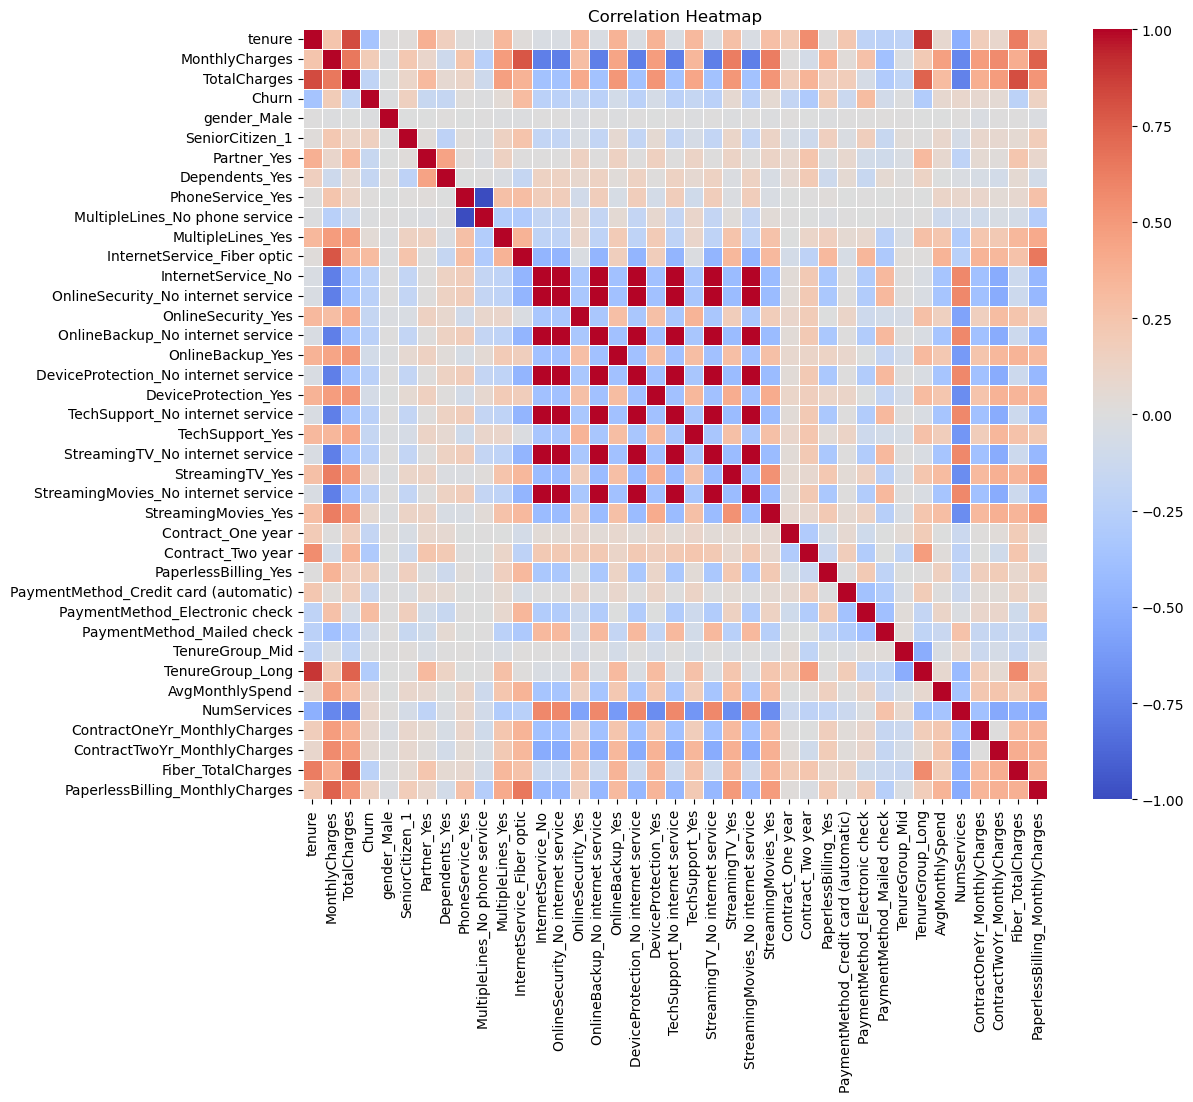

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,10))
corr = df_encoded.corr()
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

## Feature importance (using tree model)

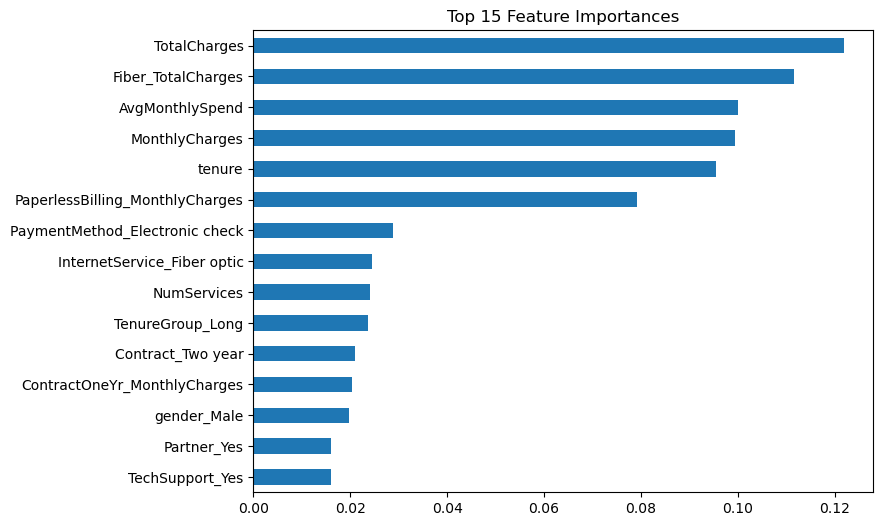

In [15]:
from sklearn.ensemble import RandomForestClassifier

# Prepare X and y
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# Fit a simple random forest
model = RandomForestClassifier(random_state=42)
model.fit(X, y)

# Show feature importance
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(15).plot(kind='barh', figsize=(8,6))
plt.title('Top 15 Feature Importances')
plt.gca().invert_yaxis()
plt.show()


# Business Insight
- There are other variables other than MonthlyCharges that are important and require further analysis and feature engineering.
- We will continue an iterative feature engineering, hyperparameter tuning.
- Version, document, and report results

# SMOTE

## Handling Class Imbalance
The dataset is imbalanced: The majority of customers did not churn ~ 76%
To address this imbalnce, we use SMOTE technique.

In [16]:
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# Make sure X is numeric (after encoding) and y is binary (0/1)

# y = df_encoded['Churn'].map({'No': 0, 'Yes': 1}) - 
#X = df_encoded.drop('Churn', axis=1)

print("Before resampling: ")
print(y.value_counts())

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("\nAfter SMOTE resampling:")
print(y_resampled.value_counts())

Before resampling: 
0    5174
1    1869
Name: Churn, dtype: int64

After SMOTE resampling:
0    5174
1    5174
Name: Churn, dtype: int64


## Save resampled dataset 

In [18]:
from preprocess import save_processed_data

# Save processed data
filename = save_processed_data(X_resampled, y_resampled)

✅ Saved processed data to: ../data/processed/.csv


In [ ]:
sl